# Regresión lineal simple
---

***Tenga en cuenta que este script es una guía para ayudar en la resolución de los ejercicios. Las consignas, incisos, datasets, tablas, parámetros y/o demás valores utilizados pueden no coincidir con los de la práctica.***

**Montar la carpeta de Google Drive y definir constantes para trabajar**

In [1]:
MNT_DRIVE_DIR = '/content/drive/'
DRIVE_DIR = '/content/drive/MyDrive/'
DATOS_DIR = DRIVE_DIR + 'Colab Notebooks/DATOS/'
FUENTES_DIR = DRIVE_DIR + 'Colab Notebooks/FUENTES'

from google.colab import drive
drive.mount(MNT_DRIVE_DIR)

# agrega ruta de busqueda donde tenemos archivos .py
import sys
sys.path.append(FUENTES_DIR)

ModuleNotFoundError: No module named 'google.colab'

#    Variantes del Descenso del Gradiente
**Descenso del Gradiente por Lotes (Batch Gradient Descent):**

* Calcula el gradiente utilizando todo el conjunto de datos en cada época.
* Ajusta los pesos una vez por época en función del gradiente global promedio.
* Adecuado para conjuntos de datos pequeños o medianos, pero costoso en conjuntos de datos grandes.

**Descenso de Gradiente Estocástico (Stocastic Gradient Descent):**

* Calcula el gradiente utilizando un solo ejemplo a la vez en cada iteración.
* Ajusta los pesos después de cada ejemplo.
* Converge más rápido, especialmente en conjuntos de datos grandes, pero con mayor variabilidad en la dirección del gradiente debido a la estocasticidad.

**Descenso del Gradiente por Mini-lotes (Mini-Batch Gradient Descent):**

* Calcula el gradiente utilizando un mini-lote (un pequeño subconjunto de ejemplos) en cada iteración.
* Ajusta los pesos después de cada mini-lote.
* Equilibra la eficiencia y la estabilidad del gradiente, utilizado comúnmente en prácticas de entrenamiento.

---

**Error Cuadrático Medio  (Mean Square Error)**
$$
MSE = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 \\
$$


Donde:

- $MSE$ es el Error Cuadrático Medio.
- $m$ es el número de observaciones o ejemplos del conjunto de datos.
- $y_i$ es el valor real (que intenta predecir el modelo) del ejemplo $i$.
- $\hat{y}_i$ es el valor predicho por el modelo para el ejemplo $i$.




---
Este ejemplo ilustra la relación entre las horas de estudio dedicadas por un grupo de estudiantes y las notas obtenidas en una evaluación (en una escala de 0 a 10). Se busca explorar si existe una correlación positiva entre el tiempo invertido en estudiar y el rendimiento académico. Los datos se grafican en un diagrama de dispersión, y se calcula el coeficiente de correlación de Pearson para cuantificar esta relación. Aunque la tendencia general es que más horas de estudio se asocian con mejores notas, también se incluye cierta variabilidad para reflejar diferencias individuales (como eficiencia de estudio, conocimientos previos, etc.).

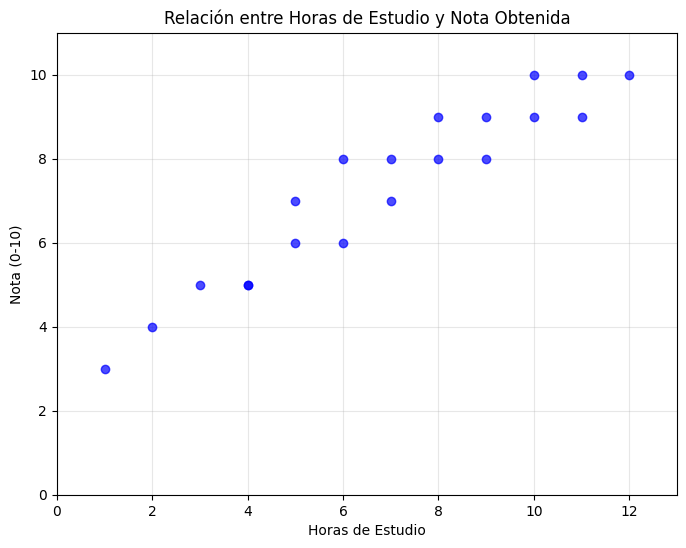

Coeficiente de correlación (Pearson): 0.954


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

# Nuevos valores para "Horas de Estudio" (entre 1 y 12 horas)
horas_estudio = [1, 2, 3, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 4]

# Notas correspondientes (escala 0-10), con tendencia positiva pero algo de ruido
nota_materia = [3, 4, 5, 5, 6, 7, 6, 8, 7, 8, 8, 9, 8, 9, 9, 10, 9, 10, 10, 5]

X = np.array(horas_estudio)
Y = np.array(nota_materia)

# Gráfica de dispersión
plt.figure(figsize=(8, 6))
plt.plot(X, Y, 'o', color='blue', alpha=0.7, markersize=6)
plt.title('Relación entre Horas de Estudio y Nota Obtenida')
plt.xlabel('Horas de Estudio')
plt.ylabel('Nota (0-10)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 13)
plt.ylim(0, 11)
plt.show()

# Cálculo del coeficiente de correlación
correlacion = np.corrcoef(X, Y)[0, 1]
print(f"Coeficiente de correlación (Pearson): {correlacion:.3f}")

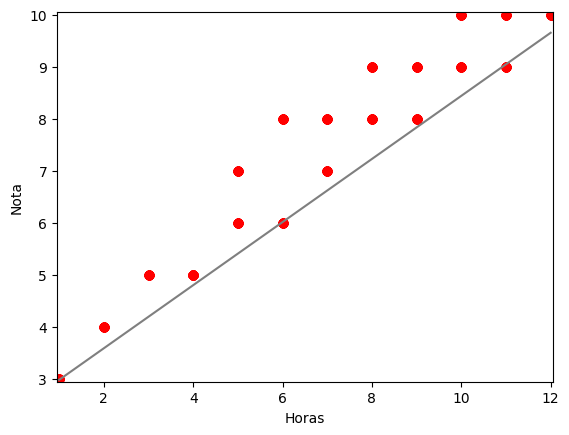

w = 0.6061396021278366
b = 2.3801304376339196
Errores:
  0 => 154.498886
  1 => 36.039934
  2 => 35.038045
  3 => 34.085031
  4 => 33.178565
  5 => 32.316427
  6 => 31.496503
  7 => 30.716778
  8 => 29.975332
  9 => 29.270336
 10 => 28.600047
 11 => 27.962804
 12 => 27.357024
 13 => 26.781201
 14 => 26.233898
 15 => 25.713746
 16 => 25.219442
 17 => 24.749743
 18 => 24.303466
 19 => 23.879484
 20 => 23.476722
 21 => 23.094157
 22 => 22.730816
 23 => 22.385768
 24 => 22.058130
 25 => 21.747060
 26 => 21.451754
 27 => 21.171449
 28 => 20.905416
 29 => 20.652962
 30 => 20.413426
 31 => 20.186179
 32 => 19.970623
 33 => 19.766186
 34 => 19.572325
 35 => 19.388523
 36 => 19.214287
 37 => 19.049148
 38 => 18.892658
 39 => 18.744392
 40 => 18.603946
 41 => 18.470933
 42 => 18.344987
 43 => 18.225757
 44 => 18.112910
 45 => 18.006130
 46 => 17.905115
 47 => 17.809578
Quien dedicó 9 horas de estudio sacará un 7 como nota en el examen


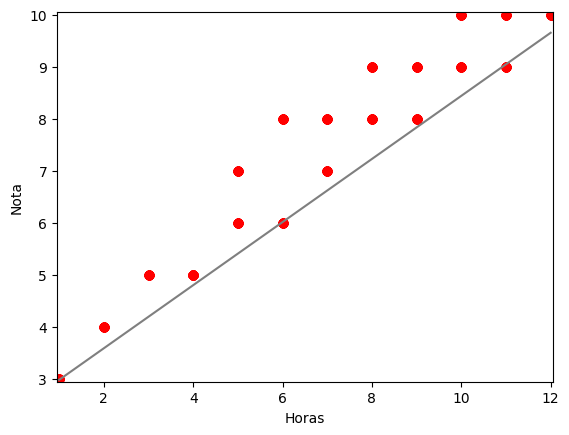

In [4]:
import sys
import os

# Ruta absoluta a la carpeta "Fuentes"
ruta_fuentes = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Fuentes"))
sys.path.append(ruta_fuentes)

from ClassNeuronaLineal import NeuronaLineal

x_train = X.reshape(-1,1)    # selecciona entradas y formatea a Nx1
y_train = Y.reshape(-1,1)    # selecciona salidas y formatea a Nx1

# entrena neurona lineal y grafica
modelo = NeuronaLineal(alpha=0.01, n_iter=500, cotaE=0.1, draw=1, title=['Horas', 'Nota'])
modelo = modelo.fit(x_train, y_train)
print('w =', modelo.w_[0])
print('b =', modelo.b_[0])

# imprime errores de cada iteracion:
print('Errores:')
for i, err in enumerate(modelo.errors_):
    print('%3d => %f' % (i, err[0]))


dato = 9 # horas de estudio dedicadas
print('Quien dedicó %d horas de estudio sacará un %d como nota en el examen' % (dato, modelo.predict([dato])[0]))   # prediccion

In [ ]:
# prueba con pesos de otro entrenamiento
#w = 0.6281767157431366
#b = 3.2010171504435605
modelo.w_ = [0.63]
modelo.b_ = [3.20]

for i in range(1, 12):
    dato = i # horas de estudio dedicadas
    print('Quien dedicó %2d horas de estudio sacará un %2d como nota en el examen' % (dato, modelo.predict([dato])[0]))   # prediccion